# TiRex: Zero-Shot Forecasting and Fine-Tuning

This notebook demonstrates how to use **TiRex** in Darts — both for **zero-shot inference** and **fine-tuning** on your own data.

TiRex is a pre-trained foundation model for time series forecasting based on xLSTM (sLSTM blocks), introduced in [Auer et al. (2025)](https://arxiv.org/abs/2505.23719) and developed by [NXAI](https://nx-ai.com).

> **License**: TiRex is distributed under the [NXAI Community License](https://github.com/NX-AI/tirex/blob/main/LICENSE). You must pass `accept_license=True` when creating the model to confirm acceptance. Organizations with annual revenue above €100M must obtain a commercial license.

## Contents

1. [Setup & Data](#1.-Setup-&-Data)
2. [Zero-Shot Inference](#2.-Zero-Shot-Inference)
3. [Probabilistic Forecasting](#3.-Probabilistic-Forecasting)
4. [Fine-Tuning](#4.-Fine-Tuning)
   - [4.1 Light Partial Fine-Tuning (output head only)](#4.1-Light-Partial-Fine-Tuning)
   - [4.2 Deeper Partial Fine-Tuning (last 4 blocks + output head)](#4.2-Deeper-Partial-Fine-Tuning)
5. [Save & Load a Fine-Tuned Model](#5.-Save-&-Load-a-Fine-Tuned-Model)

In [1]:
# fix python path if working locally
from utils import fix_pythonpath_if_working_locally

fix_pythonpath_if_working_locally()
%matplotlib inline

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import logging
import os
import warnings

import matplotlib.pyplot as plt

from darts import set_option
from darts.datasets import AirPassengersDataset, AusBeerDataset
from darts.metrics import mae
from darts.models import TiRexModel
from darts.utils.callbacks import TFMProgressBar
from darts.utils.likelihood_models import QuantileRegression

warnings.filterwarnings("ignore")
logging.disable(logging.CRITICAL)
set_option("plotting.use_darts_style", True)

## 1. Setup & Data

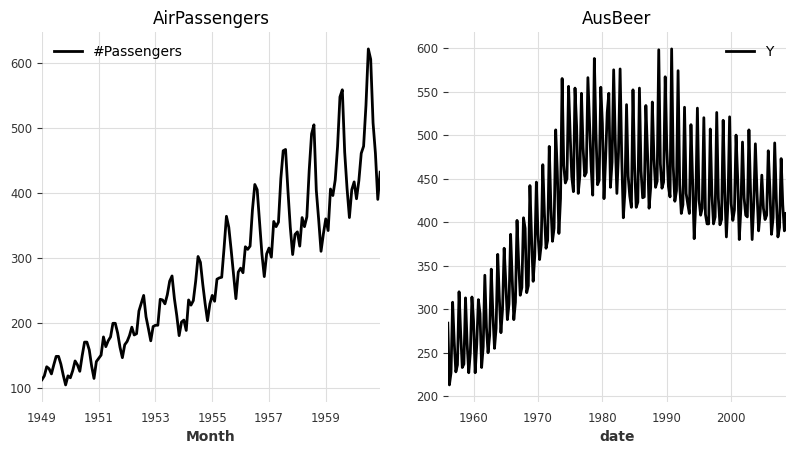

In [4]:
input_chunk_length = 24
output_chunk_length = 12

series_air = AirPassengersDataset().load().astype("float32")
series_beer = AusBeerDataset().load().astype("float32")

fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(9.6, 4.8))
series_air.plot(ax=ax1, title="AirPassengers")
series_beer.plot(ax=ax2, title="AusBeer")

train_beer = series_beer[: -2 * output_chunk_length]
val_beer = series_beer[
    -(2 * output_chunk_length + input_chunk_length) : -output_chunk_length
]

## 2. Zero-Shot Inference

TiRex is licensed under the NXAI Community License — https://github.com/NX-AI/tirex/blob/main/LICENSE
Fine-tuned weights are derivative works subject to the same terms.


Predicting: |          | 0/? [00:00<?, ?it/s]

<Axes: title={'center': 'TiRex zero-shot; MAE 22.46'}, xlabel='date'>

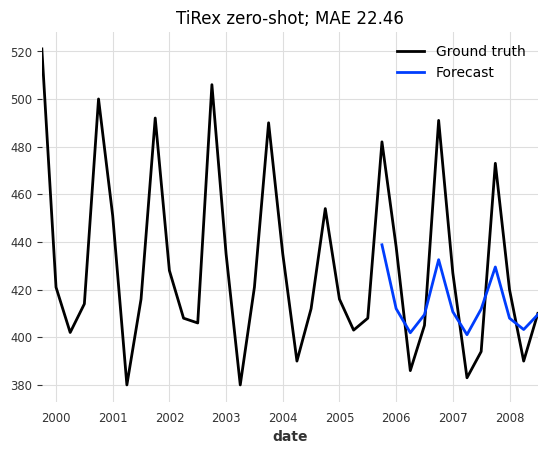

In [5]:
model_params = dict(
    input_chunk_length=input_chunk_length,
    output_chunk_length=output_chunk_length,
    accept_license=True,
    random_state=42,
)

model = TiRexModel(**model_params)
model.fit(series=train_beer)
pred_zero_shot = model.predict(n=output_chunk_length, series=val_beer)

series_beer[-3 * output_chunk_length :].plot(label="Ground truth")
pred_zero_shot.plot(
    label="Forecast",
    title=f"TiRex zero-shot; MAE {mae(series_beer, pred_zero_shot):.2f}",
)

## 3. Probabilistic Forecasting

TiRex natively outputs 9 quantiles (0.1 to 0.9). Pass a `QuantileRegression` likelihood with any subset to get probabilistic forecasts. Using `num_samples` draws from the distribution and enables darts' native CI plotting.

TiRex is licensed under the NXAI Community License — https://github.com/NX-AI/tirex/blob/main/LICENSE
Fine-tuned weights are derivative works subject to the same terms.


Predicting: |          | 0/? [00:00<?, ?it/s]

Text(0.5, 1.0, 'TiRex zero-shot — probabilistic forecast (80% CI)')

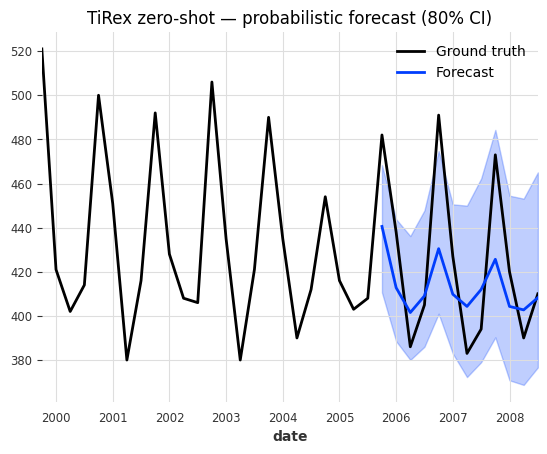

In [6]:
model_prob = TiRexModel(
    likelihood=QuantileRegression(quantiles=[0.1, 0.5, 0.9]), **model_params
)
model_prob.fit(series=train_beer)

pred_prob = model_prob.predict(n=output_chunk_length, series=val_beer, num_samples=200)

series_beer[-3 * output_chunk_length :].plot(label="Ground truth")
pred_prob.plot(label="Forecast", low_quantile=0.1, high_quantile=0.9)
plt.title("TiRex zero-shot — probabilistic forecast (80% CI)")

## 4. Fine-Tuning

### Fine-tunable layers in TiRex

TiRex uses sLSTM blocks with bfloat16 recurrence. Backpropagating through the time-loop in the **first 8 blocks** produces NaN gradients on the first backward pass — this is a structural precision constraint, not a learning rate issue. The safe fine-tunable region is:

| Layer group | Trainable params | Gradient-safe? |
|---|---|---|
| `output_patch_embedding` + `out_norm` | ~1.8M | ✓ |
| Last 4 blocks (8–11) + output head | ~12.6M | ✓ |
| First 8 blocks or full model | all | ✗ NaN gradients |

<div class="alert alert-warning" role="alert">
  <b>Backend requirement</b>: Fine-tuning requires <code>tirex_kwargs={"backend": "torch"}</code>.
</div>

### 4.1 Light Partial Fine-Tuning

Safest option: fine-tune only the **output projection head** (`output_patch_embedding` + `out_norm`), ~1.8M parameters.

TiRex is licensed under the NXAI Community License — https://github.com/NX-AI/tirex/blob/main/LICENSE
Fine-tuned weights are derivative works subject to the same terms.


Training: 0it [00:00, ?it/s]

<Axes: title={'center': 'TiRex: zero-shot vs. light partial fine-tuning'}, xlabel='date'>

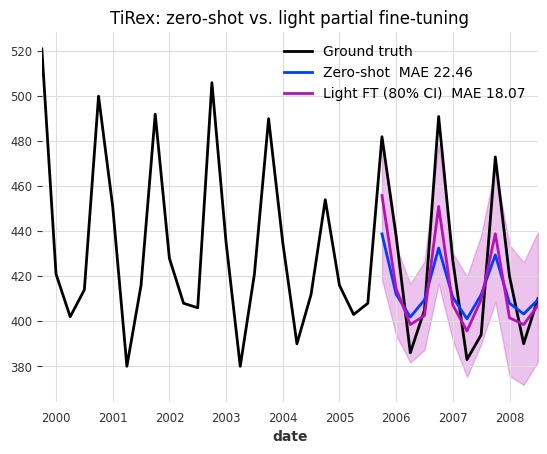

In [7]:
model_light = TiRexModel(
    likelihood=QuantileRegression(quantiles=[0.1, 0.5, 0.9]),
    enable_finetuning={
        "unfreeze": [
            "tirex_pipeline.output_patch_embedding*",
            "tirex_pipeline.out_norm*",
        ]
    },
    tirex_kwargs={"backend": "torch"},
    save_checkpoints=True,
    model_name="tirex_light",
    force_reset=True,
    optimizer_kwargs={"lr": 1e-3},
    pl_trainer_kwargs=dict(
        check_val_every_n_epoch=5,
        gradient_clip_val=1.0,
        callbacks=[TFMProgressBar(enable_train_bar_only=True)],
    ),
    **model_params,
)
model_light.fit(series=train_beer, val_series=val_beer, load_best=True, epochs=15)
pred_light = model_light.predict(
    n=output_chunk_length, series=val_beer, num_samples=200
)

series_beer[-3 * output_chunk_length :].plot(label="Ground truth")
pred_zero_shot.plot(label=f"Zero-shot  MAE {mae(series_beer, pred_zero_shot):.2f}")
pred_light.plot(
    label=f"Light FT (80% CI)  MAE {mae(series_beer, pred_light):.2f}",
    low_quantile=0.1,
    high_quantile=0.9,
    title="TiRex: zero-shot vs. light partial fine-tuning",
)

### 4.2 Deeper Partial Fine-Tuning

More capacity: unfreeze the **last 4 sLSTM blocks (8–11) plus the output head** — ~12.6M trainable parameters, still gradient-safe.

TiRex is licensed under the NXAI Community License — https://github.com/NX-AI/tirex/blob/main/LICENSE
Fine-tuned weights are derivative works subject to the same terms.


Training: 0it [00:00, ?it/s]

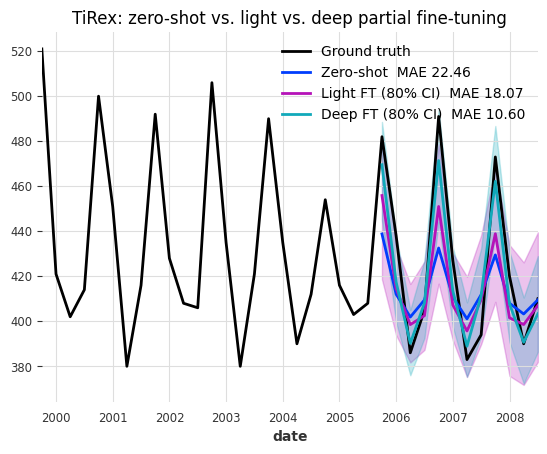

In [8]:
model_deep = TiRexModel(
    likelihood=QuantileRegression(quantiles=[0.1, 0.5, 0.9]),
    enable_finetuning={
        "unfreeze": [
            "tirex_pipeline.blocks.8.*",
            "tirex_pipeline.blocks.9.*",
            "tirex_pipeline.blocks.10.*",
            "tirex_pipeline.blocks.11.*",
            "tirex_pipeline.out_norm*",
            "tirex_pipeline.output_patch_embedding*",
        ]
    },
    tirex_kwargs={"backend": "torch"},
    save_checkpoints=True,
    model_name="tirex_deep",
    force_reset=True,
    optimizer_kwargs={"lr": 1e-4},
    pl_trainer_kwargs=dict(
        check_val_every_n_epoch=5,
        gradient_clip_val=1.0,
        callbacks=[TFMProgressBar(enable_train_bar_only=True)],
    ),
    **model_params,
)
model_deep.fit(series=train_beer, val_series=val_beer, load_best=True, epochs=15)
pred_deep = model_deep.predict(n=output_chunk_length, series=val_beer, num_samples=200)

series_beer[-3 * output_chunk_length :].plot(label="Ground truth")
pred_zero_shot.plot(label=f"Zero-shot  MAE {mae(series_beer, pred_zero_shot):.2f}")
pred_light.plot(
    label=f"Light FT (80% CI)  MAE {mae(series_beer, pred_light):.2f}",
    low_quantile=0.1,
    high_quantile=0.9,
)
pred_deep.plot(
    label=f"Deep FT (80% CI)  MAE {mae(series_beer, pred_deep):.2f}",
    low_quantile=0.1,
    high_quantile=0.9,
    title="TiRex: zero-shot vs. light vs. deep partial fine-tuning",
)
plt.legend(loc="upper right")

## 5. Save & Load a Fine-Tuned Model

Model saved to darts_logs/tirex_deep.pt


<Axes: title={'center': 'TiRex: save & load round-trip'}, xlabel='date'>

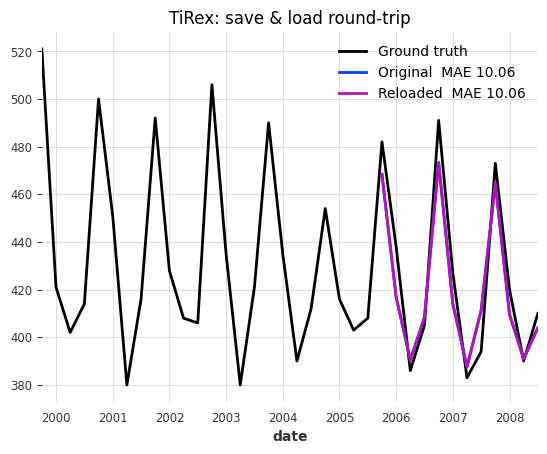

In [9]:
save_path = os.path.join("darts_logs", "tirex_deep.pt")
os.makedirs("darts_logs", exist_ok=True)
model_deep.save(save_path)
print(f"Model saved to {save_path}")

model_loaded = TiRexModel.load(save_path)

# predict_likelihood_parameters=True is deterministic — no stochastic sampling
pred_orig = model_deep.predict(
    n=output_chunk_length, series=val_beer, predict_likelihood_parameters=True
)
pred_reloaded = model_loaded.predict(
    n=output_chunk_length, series=val_beer, predict_likelihood_parameters=True
)
median_orig = pred_orig[pred_orig.components[1]]  # q0.5
median_reloaded = pred_reloaded[pred_reloaded.components[1]]

series_beer[-3 * output_chunk_length :].plot(label="Ground truth")
median_orig.plot(label=f"Original  MAE {mae(series_beer, median_orig):.2f}")
median_reloaded.plot(
    label=f"Reloaded  MAE {mae(series_beer, median_reloaded):.2f}",
    title="TiRex: save & load round-trip",
)

## Summary

| Mode | `enable_finetuning` | Params | LR | Notes |
|---|---|---|---|---|
| Zero-shot | `False` | 0 | — | No training |
| Light | `{"unfreeze": ["tirex_pipeline.output_patch_embedding*", "tirex_pipeline.out_norm*"]}` | ~1.8M | 1e-3 | Safest |
| Deep | `{"unfreeze": ["tirex_pipeline.blocks.8.*", ..., "tirex_pipeline.output_patch_embedding*"]}` | ~12.6M | 1e-4 | More capacity |
| Full | `True` | all | — | **Not supported** — NaN gradients |

**Tips**:
- Always use `tirex_kwargs={"backend": "torch"}` when fine-tuning.
- Use `gradient_clip_val=1.0` and `save_checkpoints=True` + `load_best=True`.
- TiRex trains on all 9 quantiles internally and returns only your requested subset at prediction time.

**License**: TiRex is licensed under the [NXAI Community License](https://github.com/NX-AI/tirex/blob/main/LICENSE). Fine-tuned weights are derivative works subject to the same terms.